In [ ]:
from core.bot import Plankton
from train.dataset import SelfPlayENV

import torch
from tqdm import tqdm
from torch.optim import AdamW

from matplotlib import pyplot as plt

# Training

In [2]:
num_param = lambda m: sum(p.numel() for p in m.parameters())

def loss_func(moves, indices, reward):
    log_probs = []
    for prob, idx in zip(moves, indices):
        log_probs.append(torch.log(prob[idx] + 1e-9))
    log_probs = torch.stack(log_probs).sum()
    
    entropy = [-(p * torch.log(p + 1e-9)).sum() for p in moves]
    entropy = torch.stack(entropy).mean()

    loss = -(reward * log_probs) - 0.5 * entropy
    return loss

def train(env, opt, games=1):
    hist_reward = []
    buffer_rewards = []

    for _ in tqdm(range(games), "Games"):
        moves, indices, reward = env()
        hist_reward.append(reward)

        buffer_rewards.append(reward)
        buffer_rewards = buffer_rewards[-50:]
        baseline = sum(buffer_rewards) / (len(buffer_rewards) + 1e-9)

        reward = reward - baseline
        loss = loss_func(moves, indices, reward)

        loss.backward()
        opt.step()
        opt.zero_grad()

    return hist_reward

In [3]:
plankton = Plankton()
env = SelfPlayENV(plankton, 100)
opt = AdamW(
    plankton.parameters(),
    lr=1e-3,
    weight_decay=0.01,
)

print("Numerical parameters in the model:", num_param(plankton))

Numerical parameters in the model: 13923


Games: 100%|██████████| 100/100 [04:39<00:00,  2.79s/it]


Mean rewards: -0.02000
Mean rewards[100]: -0.02000


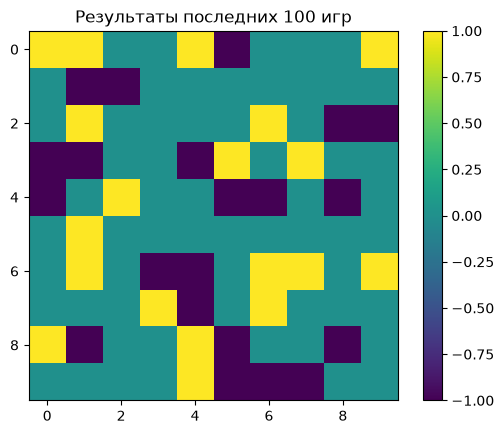

In [4]:
hist = train(
    env = env,
    opt = opt,
    games = 100,
)

print(f"Mean rewards: {sum(hist)/len(hist):.5f}")
print(f"Mean rewards[100]: {sum(hist[-100:])/100:.5f}")
plt.imshow(torch.tensor(hist)[-100:].view(10, 10))
plt.title("Результаты последних 100 игр")
plt.colorbar()
plt.show()

# Testing

In [9]:
import chess
import random

board = chess.Board()
env.trainee.eval()
print("ok")

ok


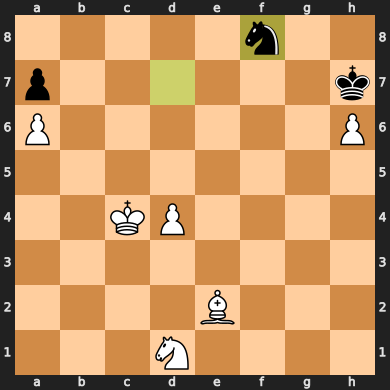

In [171]:
# Random moves
move_white = random.choice(list(board.legal_moves))
board.push(move_white)

with torch.inference_mode():
    board_ten = env.board_to_tensor(board.board_fen())
    ctx = env.board_to_ctx(board)
    out = env.trainee(board_ten, ctx)
    probs, legal_moves = env.get_action_probs(board, out)
    move_idx = probs.argmax().item()
    move = legal_moves[move_idx]
    board.push(move)

board

# Save

In [212]:
import onnx
import onnxruntime as ort
import numpy as np
import time

In [220]:
# Save model

plankton.eval()
board = torch.randint(0, 13, (8, 8))
ctx = torch.rand(7)
torch.onnx.export(
    plankton,
    (board, ctx),
    "plankton.onnx",
    export_params=True,
    opset_version=26,
    do_constant_folding=True,
    input_names=["board", "context"],                  
    output_names=["move"],                             
)

onnx_model = onnx.load("plankton.onnx")
onnx.checker.check_model(onnx_model)
onnx.save(onnx_model, "plankton.onnx", save_as_external_data=False)
print("Done")

[torch.onnx] Obtain model graph for `Plankton([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Plankton([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\Himer\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 26).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Done


In [226]:
# Test CPU

session = ort.InferenceSession("plankton.onnx", providers=["CPUExecutionProvider"])
session.run(["move"], {   # тестовая прогонка
    "board": np.random.randint(0, 13, size=(8, 8)).astype(np.int64),
    "context": np.random.randn(7).astype(np.float32),
})
board = np.random.randint(0, 13, size=(10_000, 8, 8)).astype(np.int64)
ctx = np.random.randn(10_000, 7).astype(np.float32)

start = time.perf_counter_ns()
for idx in range(10_000):
    session.run(["move"], {
        "board": board[idx],
        "context": ctx[idx],
    })

end = time.perf_counter_ns()
    
print("Среднее время отклика модели на CPU:", (end - start) / 10_000, "ns")

Среднее время отклика модели на CPU: 92893.43 ns
